# Chapter 2.4: DeepFM & Deep Feature Interaction Models

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain how **DeepFM** (Guo et al., 2017) replaces manual feature engineering in Wide & Deep
2. Implement DeepFM from scratch: shared embeddings feeding both FM and DNN
3. Understand **DCN** (Deep & Cross Network, Google 2017): explicit polynomial cross layers
4. Implement DCN's cross network and compare with DeepFM
5. Describe **xDeepFM** and its Compressed Interaction Network (CIN)
6. Overview advanced models: CAN (Alibaba) and FinalNet
7. Compare multiple deep feature interaction architectures on synthetic data

## Prerequisites

- Chapters 2.1-2.3 (LR, FM, Wide & Deep)
- PyTorch experience with custom modules

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part2/chapter_2.4_deepfm.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part2/chapter_2.4_deepfm.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss

np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cpu')

## 1. From Wide & Deep to DeepFM

Wide & Deep has a key limitation: the wide component requires **manual cross-feature engineering**. DeepFM solves this by replacing the wide linear model with a **Factorization Machine**.

DeepFM architecture:

$$ \hat{y} = \sigma(y_{\text{FM}} + y_{\text{DNN}}) $$

where:
- $y_{\text{FM}} = w_0 + \sum_i w_i x_i + \sum_{i<j} \langle \mathbf{v}_i, \mathbf{v}_j \rangle x_i x_j$
- $y_{\text{DNN}} = \text{MLP}([\mathbf{e}_1, \ldots, \mathbf{e}_F])$

The key innovation: **FM and DNN share the same embedding layer**. This means:
- No manual feature engineering needed (FM learns interactions automatically)
- Embeddings benefit from both low-order (FM) and high-order (DNN) supervision
- End-to-end training with shared parameters

> **Concept:** DeepFM = FM (for explicit 2nd-order interactions) + DNN (for implicit high-order interactions), with shared embeddings. It captures both low and high-order feature interactions without any manual feature engineering.

## 2. Synthetic Data Generation

In [2]:
def generate_interaction_data(n_samples=30000, seed=42):
    """Generate CTR data with complex feature interactions."""
    rng = np.random.RandomState(seed)
    
    field_dims = [10, 5, 15, 20, 8, 24]
    n_fields = len(field_dims)
    total_features = sum(field_dims)
    offsets = np.array([0] + list(np.cumsum(field_dims[:-1])))
    
    data = np.zeros((n_samples, n_fields), dtype=np.int64)
    for f in range(n_fields):
        data[:, f] = rng.randint(0, field_dims[f], n_samples)
    
    global_data = data + offsets[np.newaxis, :]
    
    # True latent factors for 2nd-order interactions
    true_k = 4
    V = rng.randn(total_features, true_k) * 0.3
    W = rng.randn(total_features) * 0.2
    
    logits = np.zeros(n_samples)
    for i in range(n_samples):
        feats = global_data[i]
        # Linear
        logits[i] += np.sum(W[feats])
        # 2nd-order (FM-like)
        v_sum = np.sum(V[feats], axis=0)
        v_sq_sum = np.sum(V[feats] ** 2, axis=0)
        logits[i] += 0.5 * np.sum(v_sum ** 2 - v_sq_sum)
        # Higher-order (3-way interaction for some feature combos)
        logits[i] += 0.1 * np.sum(V[feats[0]] * V[feats[2]] * V[feats[4]])
    
    logits += -2.0
    probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -10, 10)))
    labels = rng.binomial(1, probs)
    
    print(f"Data: {n_samples} samples, {n_fields} fields, {total_features} features, CTR={labels.mean():.4f}")
    return global_data, labels, field_dims, offsets

data, labels, field_dims, offsets = generate_interaction_data()
total_features = sum(field_dims)
n_fields = len(field_dims)

split = 24000
X_train, X_test = data[:split], data[split:]
y_train, y_test = labels[:split], labels[split:]

Data: 30000 samples, 6 fields, 82 features, CTR=0.1512


## 3. DeepFM Implementation

In [3]:
class DeepFM(nn.Module):
    """DeepFM: FM + DNN with shared embeddings (Guo et al., 2017)."""
    
    def __init__(self, num_features, n_fields, embedding_dim=8, 
                 hidden_dims=None, dropout=0.1):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        
        self.n_fields = n_fields
        
        # Shared embedding layer
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        # FM first-order
        self.linear = nn.Embedding(num_features, 1)
        self.bias = nn.Parameter(torch.zeros(1))
        nn.init.xavier_uniform_(self.linear.weight)
        
        # DNN layers
        input_dim = n_fields * embedding_dim
        layers = []
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.dnn = nn.Sequential(*layers)
    
    def fm_layer(self, x):
        """FM component: first-order + second-order interactions."""
        # First-order
        first_order = self.linear(x).squeeze(-1).sum(dim=1) + self.bias
        
        # Second-order (using shared embeddings)
        embed = self.embedding(x)  # (batch, n_fields, k)
        sum_of_embed = embed.sum(dim=1)  # (batch, k)
        square_of_sum = sum_of_embed ** 2  # (sum v_i)^2
        sum_of_square = (embed ** 2).sum(dim=1)  # sum(v_i^2)
        second_order = 0.5 * (square_of_sum - sum_of_square).sum(dim=1)
        
        return first_order + second_order
    
    def dnn_layer(self, x):
        """DNN component using shared embeddings."""
        embed = self.embedding(x)  # (batch, n_fields, k)
        embed_flat = embed.reshape(x.size(0), -1)  # (batch, n_fields * k)
        return self.dnn(embed_flat).squeeze(-1)
    
    def forward(self, x):
        fm_out = self.fm_layer(x)
        dnn_out = self.dnn_layer(x)
        return fm_out + dnn_out

print("DeepFM defined.")
model = DeepFM(total_features, n_fields, embedding_dim=8)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

DeepFM defined.
Total parameters: 17828


## 4. DCN: Deep & Cross Network

DCN (Wang et al., Google, 2017) replaces the FM layer with a **Cross Network** that explicitly models feature crosses of arbitrary order.

The cross layer computes:

$$ \mathbf{x}_{l+1} = \mathbf{x}_0 \cdot (\mathbf{w}_l^T \mathbf{x}_l) + \mathbf{b}_l + \mathbf{x}_l $$

where $\mathbf{x}_0$ is the original input. Each cross layer increases the polynomial degree by one.

> **Concept:** After $L$ cross layers, the network models all feature interactions up to degree $L+1$. Unlike FM which only models 2nd-order, DCN can model arbitrary-order interactions efficiently.

In [4]:
class CrossNetwork(nn.Module):
    """Cross Network for explicit feature crossing (Wang et al., 2017)."""
    
    def __init__(self, input_dim, num_layers=3):
        super().__init__()
        self.num_layers = num_layers
        self.cross_weights = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim) * 0.01)
            for _ in range(num_layers)
        ])
        self.cross_biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_layers)
        ])
    
    def forward(self, x0):
        """x0: (batch, d) -- initial input."""
        x = x0
        for i in range(self.num_layers):
            # x_{l+1} = x_0 * (w_l^T x_l) + b_l + x_l
            xw = torch.sum(x * self.cross_weights[i], dim=1, keepdim=True)  # (batch, 1)
            x = x0 * xw + self.cross_biases[i] + x
        return x


class DCN(nn.Module):
    """Deep & Cross Network (Google, 2017)."""
    
    def __init__(self, num_features, n_fields, embedding_dim=8,
                 cross_layers=3, hidden_dims=None, dropout=0.1):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        input_dim = n_fields * embedding_dim
        
        # Cross Network
        self.cross_net = CrossNetwork(input_dim, cross_layers)
        
        # Deep Network
        deep_input = input_dim
        layers = []
        for h_dim in hidden_dims:
            layers.append(nn.Linear(deep_input, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            deep_input = h_dim
        self.deep = nn.Sequential(*layers)
        
        # Final projection: concat cross output + deep output
        self.output_layer = nn.Linear(input_dim + hidden_dims[-1], 1)
    
    def forward(self, x):
        embed = self.embedding(x)  # (batch, n_fields, k)
        embed_flat = embed.reshape(x.size(0), -1)  # (batch, n_fields * k)
        
        cross_out = self.cross_net(embed_flat)  # (batch, n_fields * k)
        deep_out = self.deep(embed_flat)         # (batch, hidden_dims[-1])
        
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.output_layer(combined).squeeze(-1)

print("DCN defined.")
dcn = DCN(total_features, n_fields)
print(f"DCN parameters: {sum(p.numel() for p in dcn.parameters())}")

DCN defined.
DCN parameters: 17633


## 5. Training and Comparison

In [5]:
def train_ctr_model(model, X_train, y_train, X_test, y_test,
                    epochs=25, batch_size=256, lr=0.001):
    """Train a CTR model and return history."""
    train_ds = TensorDataset(torch.LongTensor(X_train), torch.FloatTensor(y_train))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'train_loss': [], 'test_auc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        model.eval()
        with torch.no_grad():
            test_probs = torch.sigmoid(model(torch.LongTensor(X_test))).numpy()
            auc = roc_auc_score(y_test, test_probs)
        
        history['train_loss'].append(total_loss / n_batches)
        history['test_auc'].append(auc)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: loss={total_loss/n_batches:.4f}, AUC={auc:.4f}")
    
    return history

# Train DeepFM
print("=== DeepFM ===")
torch.manual_seed(42)
deepfm = DeepFM(total_features, n_fields, embedding_dim=8)
deepfm_hist = train_ctr_model(deepfm, X_train, y_train, X_test, y_test)

# Train DCN
print("\n=== DCN ===")
torch.manual_seed(42)
dcn = DCN(total_features, n_fields, embedding_dim=8, cross_layers=3)
dcn_hist = train_ctr_model(dcn, X_train, y_train, X_test, y_test)

=== DeepFM ===


  Epoch 5: loss=0.3835, AUC=0.6912


  Epoch 10: loss=0.3645, AUC=0.6973


  Epoch 15: loss=0.3468, AUC=0.6914


  Epoch 20: loss=0.3369, AUC=0.6915


...

  Epoch 5: loss=0.3969, AUC=0.6964


  Epoch 10: loss=0.3778, AUC=0.7079


  Epoch 15: loss=0.3653, AUC=0.7075


  Epoch 20: loss=0.3531, AUC=0.6971


  Epoch 25: loss=0.3449, AUC=0.6876


In [6]:
# Also train a plain DNN baseline
class DNN(nn.Module):
    """Plain DNN baseline."""
    def __init__(self, num_features, n_fields, embedding_dim=8, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        input_dim = n_fields * embedding_dim
        layers = []
        for h in hidden_dims:
            layers.extend([nn.Linear(input_dim, h), nn.ReLU(), nn.Dropout(0.1)])
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        embed = self.embedding(x).reshape(x.size(0), -1)
        return self.mlp(embed).squeeze(-1)

print("=== DNN Baseline ===")
torch.manual_seed(42)
dnn = DNN(total_features, n_fields)
dnn_hist = train_ctr_model(dnn, X_train, y_train, X_test, y_test)

=== DNN Baseline ===


  Epoch 5: loss=0.3997, AUC=0.6980


  Epoch 10: loss=0.3832, AUC=0.7009


  Epoch 15: loss=0.3701, AUC=0.7002


  Epoch 20: loss=0.3599, AUC=0.6904


  Epoch 25: loss=0.3497, AUC=0.6815


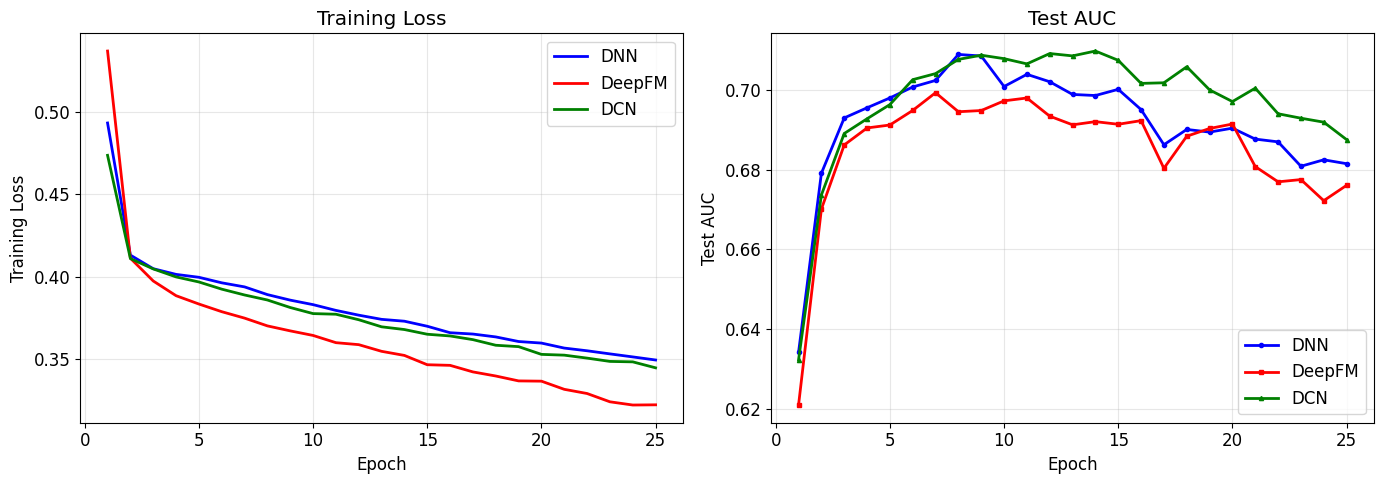

Final AUC -- DNN: 0.6815, DeepFM: 0.6761, DCN: 0.6876


In [7]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 26)

axes[0].plot(epochs, dnn_hist['train_loss'], 'b-', label='DNN', linewidth=2)
axes[0].plot(epochs, deepfm_hist['train_loss'], 'r-', label='DeepFM', linewidth=2)
axes[0].plot(epochs, dcn_hist['train_loss'], 'g-', label='DCN', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dnn_hist['test_auc'], 'b-o', label='DNN', linewidth=2, markersize=3)
axes[1].plot(epochs, deepfm_hist['test_auc'], 'r-s', label='DeepFM', linewidth=2, markersize=3)
axes[1].plot(epochs, dcn_hist['test_auc'], 'g-^', label='DCN', linewidth=2, markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final AUC -- DNN: {dnn_hist['test_auc'][-1]:.4f}, "
      f"DeepFM: {deepfm_hist['test_auc'][-1]:.4f}, "
      f"DCN: {dcn_hist['test_auc'][-1]:.4f}")

## 6. xDeepFM and Compressed Interaction Network (CIN)

**xDeepFM** (Lian et al., 2018) argues that:
- FM captures only 2nd-order explicit interactions
- DNN captures implicit high-order interactions (not interpretable)
- We need **explicit high-order** interactions

The CIN (Compressed Interaction Network) computes vector-wise interactions at each layer:

$$ X^k_{h,*} = \sum_{i=1}^{H_{k-1}} \sum_{j=1}^{m} W^{k,h}_{ij} (X^{k-1}_{i,*} \circ X^0_{j,*}) $$

where $\circ$ is the Hadamard (element-wise) product.

> **Common Pitfall:** CIN is computationally expensive -- $O(mHkD)$ per layer where $m$ is the number of fields, $H$ is hidden dimension, and $D$ is embedding dimension. In practice, keep CIN layers small.

In [8]:
class CIN(nn.Module):
    """Compressed Interaction Network (from xDeepFM, Lian et al., 2018)."""
    
    def __init__(self, n_fields, embedding_dim, cin_hidden_dims=None):
        super().__init__()
        if cin_hidden_dims is None:
            cin_hidden_dims = [16, 16]
        
        self.n_fields = n_fields
        self.cin_hidden_dims = cin_hidden_dims
        
        # CIN convolution weights
        self.conv_layers = nn.ModuleList()
        prev_dim = n_fields
        for h_dim in cin_hidden_dims:
            # Weight matrix for each CIN layer
            self.conv_layers.append(
                nn.Linear(prev_dim * n_fields, h_dim, bias=False)
            )
            prev_dim = h_dim
        
        # Output projection
        total_cin_dim = sum(cin_hidden_dims)
        self.output = nn.Linear(total_cin_dim, 1)
    
    def forward(self, x0):
        """
        x0: (batch, n_fields, embedding_dim) - field embeddings
        """
        batch_size = x0.size(0)
        embed_dim = x0.size(2)
        
        hidden_outputs = []
        x_prev = x0  # (batch, H_{k-1}, D)
        
        for i, conv in enumerate(self.conv_layers):
            # Outer product: (batch, H_{k-1}, m, D)
            # x_prev: (batch, H_{k-1}, D)
            # x0: (batch, m, D)
            z = torch.einsum('bhd,bmd->bhmd', x_prev, x0)  # (batch, H, m, D)
            z = z.reshape(batch_size, -1, embed_dim)  # (batch, H*m, D)
            
            # Apply linear transformation along the H*m dimension
            z = z.permute(0, 2, 1)  # (batch, D, H*m)
            x_next = conv(z)         # (batch, D, h_dim)
            x_next = x_next.permute(0, 2, 1)  # (batch, h_dim, D)
            x_next = torch.relu(x_next)
            
            # Sum pooling over embedding dimension
            hidden_outputs.append(x_next.sum(dim=2))  # (batch, h_dim)
            x_prev = x_next
        
        # Concatenate all CIN outputs
        cin_out = torch.cat(hidden_outputs, dim=1)  # (batch, sum(cin_hidden_dims))
        return self.output(cin_out).squeeze(-1)

# Quick test
cin = CIN(n_fields=6, embedding_dim=8, cin_hidden_dims=[16, 16])
test_input = torch.randn(4, 6, 8)
print(f"CIN output shape: {cin(test_input).shape}")
print(f"CIN parameters: {sum(p.numel() for p in cin.parameters())}")

CIN output shape: torch.Size([4])
CIN parameters: 2145


## 7. Advanced Models Overview

### CAN: Co-Action Network (Alibaba, 2020)
CAN learns **co-action units** between target item features and user behavior features using cartesian product-based micro-networks.

### FinalNet (2023)
FinalNet proposes a **feature interaction-aware** network with two variants:
- FINAL-MLP: Enhanced MLP with feature gating
- FINAL-Bi: Bilinear feature interaction with stream fusion

Both emphasize that feature interaction modeling remains key even as models grow deeper.

> **Pro Tip:** The evolution of CTR models shows a clear trend: from manual interactions (LR) to learned 2nd-order (FM) to automatic high-order (DCN, xDeepFM) to dynamic instance-aware interactions (CAN, FinalNet). Each generation reduces the need for manual feature engineering.

## 8. DCN Cross Layer Depth Analysis


Cross layers = 1:


  Epoch 5: loss=0.3962, AUC=0.6983


  Epoch 10: loss=0.3803, AUC=0.7143


  Epoch 15: loss=0.3639, AUC=0.7046

Cross layers = 2:


  Epoch 5: loss=0.3975, AUC=0.6963


...

  Epoch 10: loss=0.3811, AUC=0.7074


  Epoch 15: loss=0.3640, AUC=0.7011

Cross layers = 5:


  Epoch 5: loss=0.3961, AUC=0.7004


  Epoch 10: loss=0.3798, AUC=0.7025


  Epoch 15: loss=0.3637, AUC=0.7061


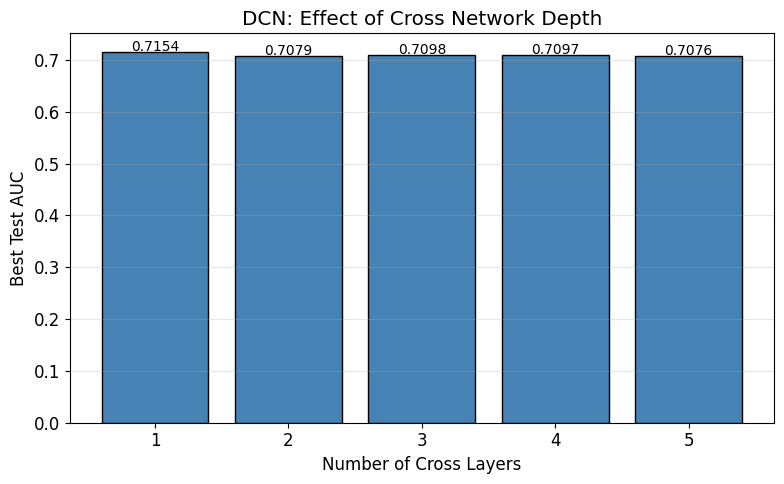

In [9]:
# How does the number of cross layers affect DCN?
cross_layer_results = {}

for n_cross in [1, 2, 3, 4, 5]:
    torch.manual_seed(42)
    model_c = DCN(total_features, n_fields, embedding_dim=8, cross_layers=n_cross)
    print(f"\nCross layers = {n_cross}:")
    hist = train_ctr_model(model_c, X_train, y_train, X_test, y_test, epochs=15)
    cross_layer_results[n_cross] = max(hist['test_auc'])

fig, ax = plt.subplots(figsize=(8, 5))
layers = list(cross_layer_results.keys())
aucs = list(cross_layer_results.values())
ax.bar(layers, aucs, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Cross Layers')
ax.set_ylabel('Best Test AUC')
ax.set_title('DCN: Effect of Cross Network Depth')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(aucs):
    ax.text(layers[i], v + 0.001, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: DeepFM Ablation Study

In [10]:
# Exercise 1: Ablation study on DeepFM components
# TODO: Train and compare:
#   a) FM only (disable DNN output)
#   b) DNN only (disable FM output)
#   c) DeepFM (both)
# Hint: You can modify the forward() method or create a flag to disable components
# TODO: Plot all three AUC curves on the same chart

# YOUR CODE HERE

### Exercise 2: Implement DCN-V2

In [11]:
# Exercise 2: DCN-V2 (Wang et al., Google, 2021)
# In DCN-V2, the cross layer uses a full matrix instead of a vector:
#   x_{l+1} = x_0 * (W_l x_l + b_l) + x_l
# where W_l is a (d x d) matrix.
# TODO: Implement DCN-V2's cross layer
# TODO: Compare DCN-V1 vs DCN-V2 on the synthetic data

class CrossNetworkV2(nn.Module):
    def __init__(self, input_dim, num_layers=3):
        super().__init__()
        # YOUR CODE HERE
        pass
    
    def forward(self, x0):
        # YOUR CODE HERE
        pass

# YOUR CODE HERE

### Exercise 3: DeepFM vs DCN on Different Data Patterns

In [12]:
# Exercise 3: When does DeepFM beat DCN and vice versa?
# TODO: Generate two datasets:
#   a) Data with strong 2nd-order interactions (should favor DeepFM)
#   b) Data with strong high-order interactions (should favor DCN)
# TODO: Train both models on both datasets
# TODO: Create a 2x2 comparison table

# YOUR CODE HERE

### Exercise 4: Shared vs Separate Embeddings

In [13]:
# Exercise 4: Does sharing embeddings actually help in DeepFM?
# TODO: Implement a version of DeepFM with SEPARATE embeddings for FM and DNN
# TODO: Compare shared vs separate embedding performance
# TODO: Measure: AUC, training speed, parameter count

# YOUR CODE HERE

## Summary

In this chapter, we covered:

1. **DeepFM** (Guo et al., 2017): FM + DNN with shared embeddings -- no manual feature engineering
2. **DCN** (Google, 2017): Cross Network for explicit polynomial interactions of arbitrary order
3. **xDeepFM** (Lian et al., 2018): CIN for explicit high-order vector-wise interactions
4. Overview of **CAN** and **FinalNet** for advanced feature interaction modeling

### Key Takeaways

- DeepFM eliminates the need for manual cross features in Wide & Deep
- DCN's cross layers model bounded-degree polynomial feature interactions efficiently
- Shared embeddings between interaction and DNN components improve training
- The field has evolved from manual to fully automatic feature interaction learning

### What's Next

In Chapter 2.5, we'll explore **attention-based CTR models** (DIN, DIEN, BST) that model user behavior sequences with attention mechanisms.